# Hyperparameter Tuning and Model Optimization

This notebook compares a few simple deep neural network settings for the Telco churn dataset.

We change learning rate, batch size, number of layers, activation function, optimizer, and epochs, then compare validation and test metrics.

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
torch.manual_seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [6]:
data_path = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
if not data_path.exists():
    matches = list(Path(".").rglob("WA_Fn-UseC_-Telco-Customer-Churn.csv"))
    if not matches:
        raise FileNotFoundError("Could not find WA_Fn-UseC_-Telco-Customer-Churn.csv")
    data_path = matches[0]

df = pd.read_csv(data_path)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()
df["Churn"] = (df["Churn"] == "Yes").astype(int)

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Rows, columns:", df.shape)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Churn rate:", round(df["Churn"].mean(), 4))

Rows, columns: (7032, 21)
Training shape: (5625, 30)
Test shape: (1407, 30)
Churn rate: 0.2658


In [7]:
def get_activation(name):
    activations = {
        "relu": nn.ReLU(),
        "tanh": nn.Tanh(),
        "sigmoid": nn.Sigmoid(),
    }
    return activations[name]


def build_model(input_dim, hidden_layers=(32,), activation="relu"):
    layers_list = []
    previous_dim = input_dim

    for units in hidden_layers:
        layers_list.append(nn.Linear(previous_dim, units))
        layers_list.append(get_activation(activation))
        previous_dim = units

    layers_list.append(nn.Linear(previous_dim, 1))
    return nn.Sequential(*layers_list)


def run_experiment(name, hidden_layers, activation, optimizer, learning_rate, batch_size, epochs):
    model = build_model(
        input_dim=X_train.shape[1],
        hidden_layers=hidden_layers,
        activation=activation,
    )

    optimizer_map = {
        "adam": torch.optim.Adam,
        "sgd": torch.optim.SGD,
        "rmsprop": torch.optim.RMSprop,
    }
    optimizer_obj = optimizer_map[optimizer](model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()

    x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)
    x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

    dataset = TensorDataset(x_train_tensor, y_train_tensor)
    val_size = max(1, int(0.2 * len(dataset)))
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:
            optimizer_obj.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer_obj.step()

            train_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            train_correct += (preds == yb).sum().item()
            train_total += xb.size(0)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)

        history["loss"].append(train_loss / train_total)
        history["accuracy"].append(train_correct / train_total)
        history["val_loss"].append(val_loss / val_total)
        history["val_accuracy"].append(val_correct / val_total)

    model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(model(x_test_tensor)).squeeze().numpy()
    preds = (test_probs >= 0.5).astype(int)

    return {
        "experiment": name,
        "hidden_layers": str(hidden_layers),
        "activation": activation,
        "optimizer": optimizer,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "val_accuracy": history["val_accuracy"][-1],
        "val_loss": history["val_loss"][-1],
        "test_accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "history": history,
        "preds": preds,
        "model": model,
    }

In [8]:
experiments = [
    {
        "name": "Baseline",
        "hidden_layers": (32,),
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
    },
    {
        "name": "More Layers",
        "hidden_layers": (64, 32),
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
    },
    {
        "name": "Tanh Activation",
        "hidden_layers": (32,),
        "activation": "tanh",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
    },
    {
        "name": "SGD Optimizer",
        "hidden_layers": (32,),
        "activation": "relu",
        "optimizer": "sgd",
        "learning_rate": 0.01,
        "batch_size": 32,
        "epochs": 15,
    },
    {
        "name": "Larger Batch + More Epochs",
        "hidden_layers": (32,),
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 25,
    },
]

results = [run_experiment(**config) for config in experiments]
summary = pd.DataFrame(
    [
        {
            "Experiment": item["experiment"],
            "Layers": item["hidden_layers"],
            "Activation": item["activation"],
            "Optimizer": item["optimizer"],
            "LR": item["learning_rate"],
            "Batch Size": item["batch_size"],
            "Epochs": item["epochs"],
            "Val Acc": round(item["val_accuracy"], 4),
            "Val Loss": round(item["val_loss"], 4),
            "Test Acc": round(item["test_accuracy"], 4),
            "Precision": round(item["precision"], 4),
            "Recall": round(item["recall"], 4),
            "F1": round(item["f1"], 4),
        }
        for item in results
    ]
).sort_values("Val Acc", ascending=False).reset_index(drop=True)

print("Comparison Table:")
display(summary)

Comparison Table:


,Experiment,Layers,Activation,Optimizer,LR,Batch Size,Epochs,Val Acc,Val Loss,Test Acc,Precision,Recall,F1
0,SGD Optimizer,"(32,)",relu,sgd,0.010,32,15,0.8027,0.4247,0.7932,0.6317,0.5321,0.5776
1,Larger Batch + More Epochs,"(32,)",relu,adam,0.001,64,25,0.8018,0.4230,0.7946,0.6276,0.5588,0.5912
2,Tanh Activation,"(32,)",tanh,adam,0.001,32,15,0.8000,0.4225,0.7953,0.6453,0.5107,0.5701
3,Baseline,"(32,)",relu,adam,0.001,32,15,0.7973,0.4213,0.7939,0.6409,0.5107,0.5685
4,More Layers,"(64, 32)",relu,adam,0.001,32,15,0.7920,0.4317,0.7903,0.6416,0.4786,0.5482


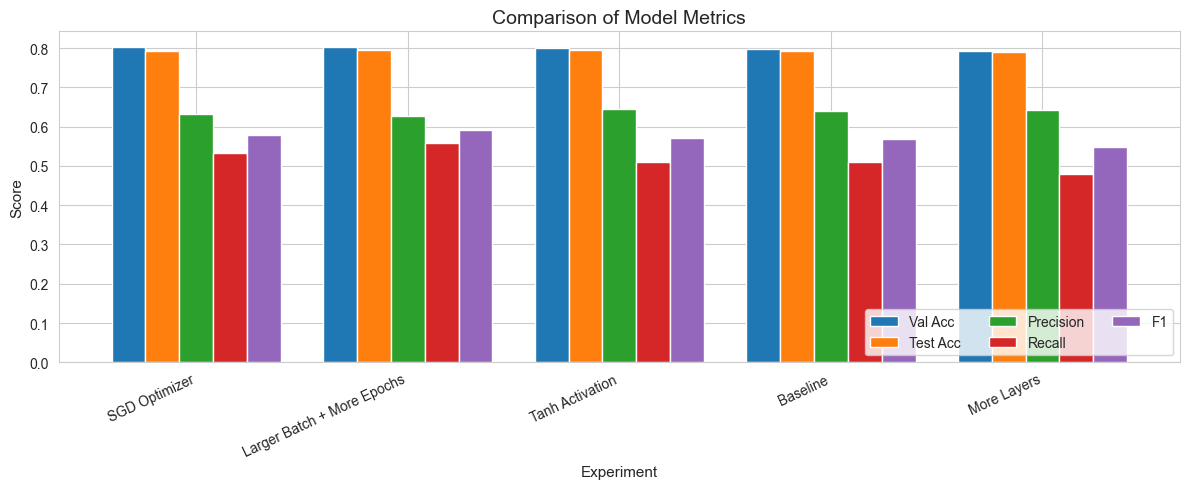

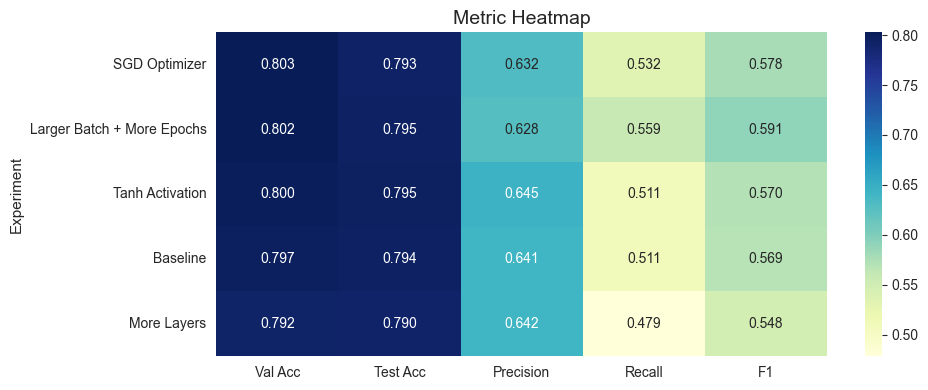

Best experiment: SGD Optimizer


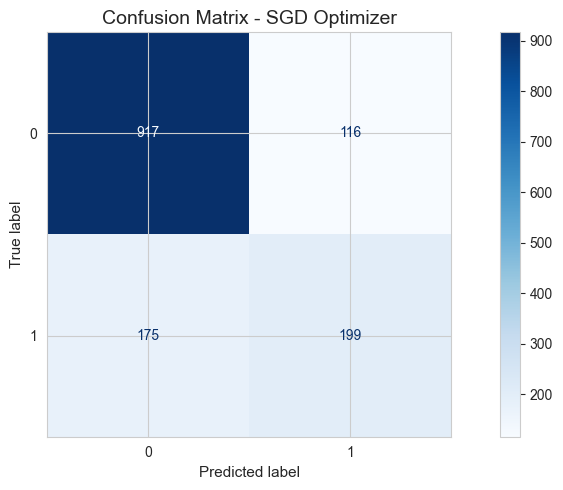

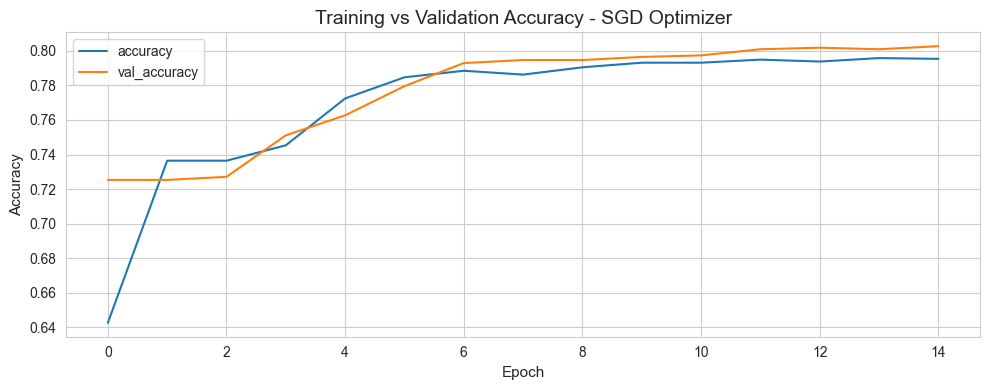

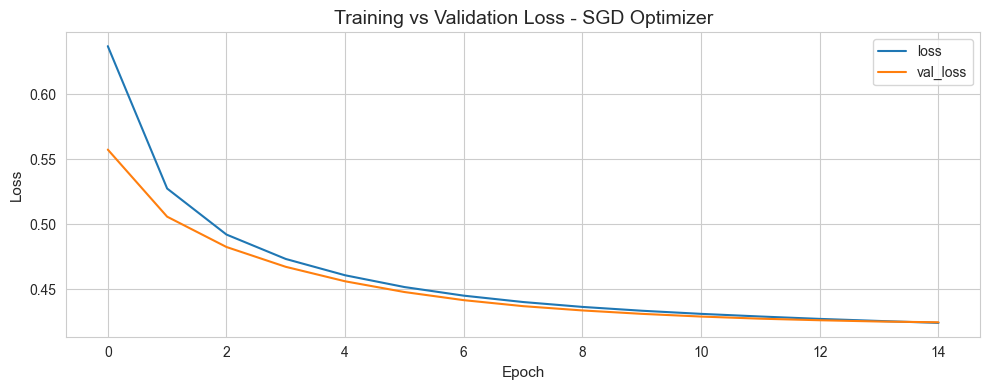

In [9]:
metric_cols = ["Val Acc", "Test Acc", "Precision", "Recall", "F1"]
comparison = summary.set_index("Experiment")[metric_cols]

ax = comparison.plot(kind="bar", figsize=(12, 5), width=0.8)
ax.set_title("Comparison of Model Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Experiment")
ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(comparison, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Metric Heatmap")
plt.tight_layout()
plt.show()

best_result = max(results, key=lambda item: item["val_accuracy"])
print("Best experiment:", best_result["experiment"])

cm = confusion_matrix(y_test, best_result["preds"])
ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_result['experiment']}")
plt.tight_layout()
plt.show()

history_df = pd.DataFrame(best_result["history"])
ax = history_df[["accuracy", "val_accuracy"]].plot(figsize=(10, 4))
ax.set_title(f"Training vs Validation Accuracy - {best_result['experiment']}")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

history_df[["loss", "val_loss"]].plot(figsize=(10, 4))
plt.title(f"Training vs Validation Loss - {best_result['experiment']}")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()